# Pattern Recognition & Feature Extraction with OpenCV

In this sixth and final blog, we will cover some more common and powerful pattern recognition and feature extraction techniques.

In [1]:
# @title Contact Software Sushi {"display-mode":"form"}
import base64
import requests
import urllib.request
from IPython.display import display, HTML

image_url = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/company/logo.png"
with urllib.request.urlopen(image_url) as response:
    image_data = response.read()
    encoded_image = base64.b64encode(image_data).decode()

def load_html_from_github(raw_url):
    response = requests.get(raw_url)
    html_content = response.text
    updated_html = html_content.replace('../images/logo.png', f"data:image/png;base64, {encoded_image}")
    display(HTML(updated_html))

load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner-with-logo.html')

### Imports & Sample Images

In [2]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import base64

from IPython.display import HTML, display
from io import BytesIO
from PIL import Image

In [3]:
# Collecting the sample image
image_url = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv_blog/part_6/Parrot_in_snow.png"
resp = urllib.request.urlopen(image_url)
image_bytes = np.asarray(bytearray(resp.read()), dtype=np.uint8)

image_url_2 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv_blog/part_6/Parrot_in_snow_template.png"
resp_2 = urllib.request.urlopen(image_url_2)
image_bytes_2 = np.asarray(bytearray(resp_2.read()), dtype=np.uint8)

image_url_3 = "https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/main/images/opencv_blog/part_6/Parrot_in_snow_sun.png"
resp_3 = urllib.request.urlopen(image_url_3)
image_bytes_3 = np.asarray(bytearray(resp_3.read()), dtype=np.uint8)

###Utils###

In [5]:
# Function for the creation of flexible MatPlotLib figures
def create_mpl_figure(w,h,images,titles="Image",axis="off",color_maps=None):
    plt.figure(figsize=[w,h])

    for i, image in enumerate(images):
        plt.subplot(1,len(images),i+1);

        if color_maps is None:
            plt.imshow(image);
        elif len(color_maps) > 1:
            plt.imshow(image, cmap=f"{color_maps[i]}");
        else:
            plt.imshow(image, cmap=f"{color_maps[0]}")

        plt.title(titles[i]);
        plt.axis(axis);

def display_image_gallery(
    images, titles=None, img_width=200, fmt="png"
):
    if titles is None:
        titles = [''] * len(images)
    if len(images) != len(titles):
        raise ValueError("`images` and `titles` must be the same length.")

    def to_pil(arr):
        if isinstance(arr, Image.Image):
            return arr
        if arr.dtype != np.uint8:
            arr = np.clip(arr, 0, 255).astype("uint8")
        if arr.ndim == 2:
            return Image.fromarray(arr, mode="L")
        if arr.shape[2] == 3:
            return Image.fromarray(arr, mode="RGB")
        if arr.shape[2] == 4:
            return Image.fromarray(arr, mode="RGBA")
        raise ValueError("Unsupported array shape.")

    blocks = []
    for img, cap in zip(images, titles):
        pil = to_pil(img)
        buf = BytesIO(); pil.save(buf, format=fmt.upper())
        data_uri = f"data:image/{fmt};base64,{base64.b64encode(buf.getvalue()).decode()}"
        wstyle = f"width:{img_width}px;" if img_width is not None else ""
        blocks.append(f"""
          <figure style="display:flex;flex-direction:column;align-items:center;margin:0;">
             <figcaption style="color:#000;font:14px/1.2 sans-serif;margin:0 0 4px 0;">
                {cap}
             </figcaption>
             <img src="{data_uri}" style="{wstyle}height:auto;display:block;">
          </figure>
        """)

    html = f"""
    <div style="
         display:inline-flex;
         gap:10px;
         padding:10px;
         background:#fff;
         border-radius:4px;">
        {''.join(blocks)}
    </div>
    """
    display(HTML(html))

## List of Techniques

* Template Matching
* Fourier Transform
* Hough Line Transform
* Hough Circle Transform
* Histogram Equalization

## Use Cases

Whether it be lane and road edge detection in the automotive industry with Hough Line Transform, or making the images that come out of MRIs and CT scans clearer using Histogram Equalization, each of the techniques covered in this blog are very flexible, with each of them having a significant variety of different applications in a large number of different industries.

## Techniques

### Template Matching

**What it does:** Template Matching is a technique that takes two images, the source image, and the template image. This technique evaluates the source image, attempting to find an instance of the template image within it.

**Why it matters:** Template matching is very useful for object detection, provided scale and rotation remain constant between the template and the source image.

**The Code & Output**

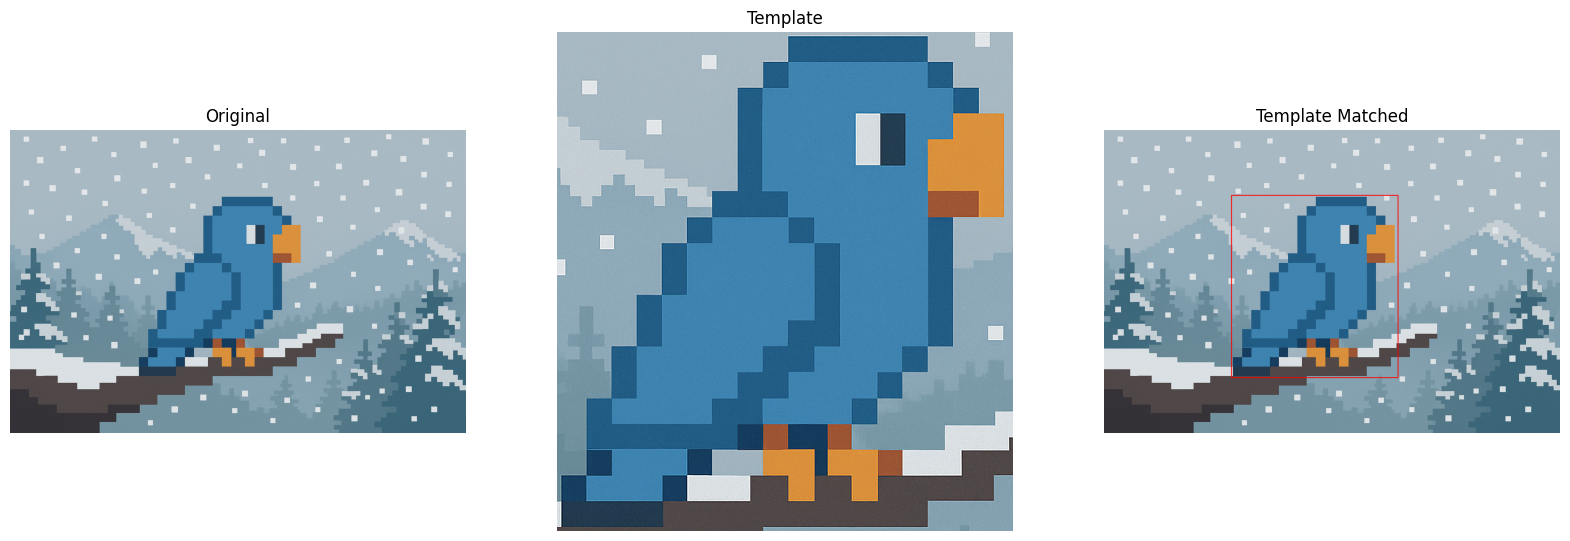

In [17]:
# Reading the sample image
bgr_img = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
img_matched = img.copy()

# Reading the template image
template_bgr = cv2.imdecode(image_bytes_2, cv2.IMREAD_COLOR)
template = cv2.cvtColor(template_bgr, cv2.COLOR_BGR2RGB)

# Template Matching
h,w = template.shape[:2]

template_match = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(template_match)

top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

cv2.rectangle(img_matched, top_left, bottom_right, (255, 0, 0), 2)

# Creation of an MPL figure for displaying images
create_mpl_figure(20, 10, [img, template, img_matched], [ "Original", "Template", "Template Matched"])

### Fourier Transform

**What it does:** The Fourier Transform technique takes an image, and rather than displaying the regular "pixel view", it instead shifts to a view of the patterns of change within that image, the "frequency view" of the image that shows how often things change within the image.

**Why it matters:** Fourier Tranforms are commonly used for noise removal, image compression, and pattern / texture recognition.

**The Code & Output**

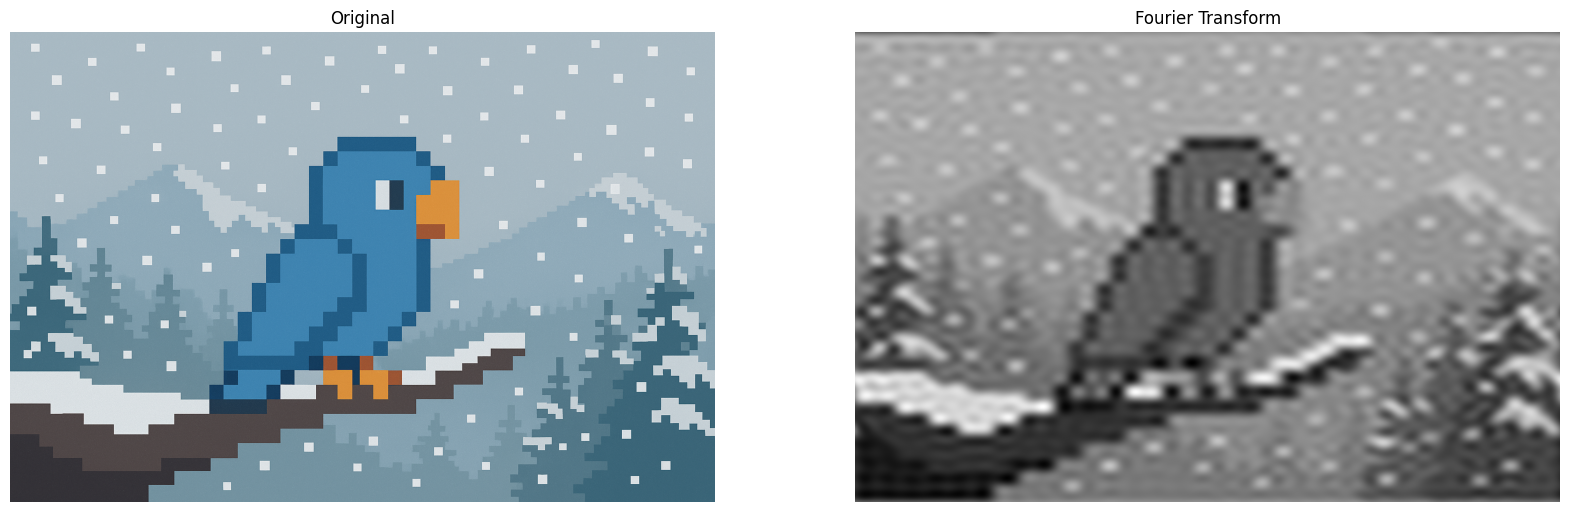

In [7]:
# Reading the sample image
bgr_img = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Fourier Transform
dft = cv2.dft(np.float32(img_gray), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)  # Move low frequencies to center

# Step 3: Create a low-pass filter mask
rows, cols = img_gray.shape
center_row, center_col = rows // 2, cols // 2  # Center of image

# Create a mask with 1s in a small square in the center, 0s elsewhere
mask = np.zeros((rows, cols, 2), np.uint8)
r = 30  # Radius of low-frequency region to keep (adjust to control blur)
mask[center_row - r:center_row + r, center_col - r:center_col + r] = 1

# Step 4: Apply the mask to the shifted DFT
fshift = dft_shift * mask

# Step 5: Inverse shift and inverse DFT to get back the blurred image
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])


# Creation of an MPL figure for displaying images
create_mpl_figure(20, 10, [img, img_back], ["Original", "Fourier Transform"], color_maps=["gray"])

### Hough Line Transform

**What it does:** The Hough Line Transform technique takes an image and detects straight lines within that image.

**Why it matters:** The Hough Line Transform is often used for lane and road edge detection in lane keeping assist systems, as well as in self driving cars, physical surface detection in VR / AR gaming systems, and in document processing it can assist in detecting lines and correcting skewed inputs to name a few uses.

**The Code & Output**

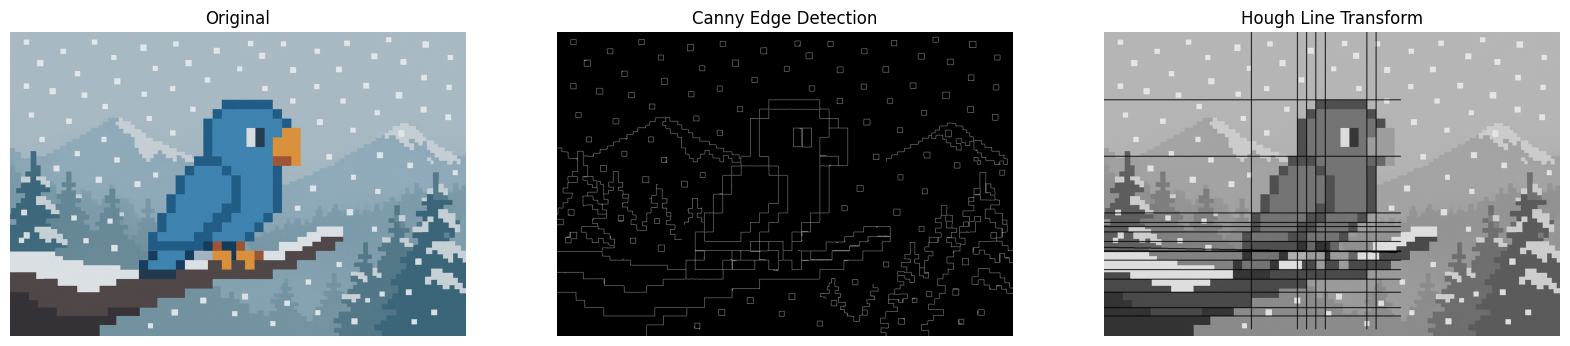

In [16]:
# Reading the sample image
bgr_img = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Image pre-processing
edges = cv2.Canny(img_gray, 35, 150)

# Hough Line Transform
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

for rho_theta in lines:
    arr = np.array(rho_theta[0], dtype=np.float64)
    r, theta = arr
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*r
    y0 = b*r
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))

    cv2.line(img_gray, (x1, y1), (x2, y2), (0, 0, 255), 2)

# You will notice not all ines are being detected. This is because there is a threshold on line length
# that will determine whether or not they are drawn on the image. You can adjust this by changing the fourth argument
# in the HoughLines method

# Creation of an MPL figure for displaying images
create_mpl_figure(20, 10, [img, edges, img_gray], ["Original", "Canny Edge Detection", "Hough Line Transform"], color_maps=["gray"])

### Hough Circle Transform

**What it does:** The Hough Circle Transform technique takes an image and detects if there are any circles within that image.

**Why it matters:** The hough circle transform is used in object detection on manufacturing lines to ensure the presence of a given product, as a quality control to measure to ensure circularity of products that ought to be so, as well as in other applications like astronomy to assist in planetary detection within telescopic images.

**The Code & Output**

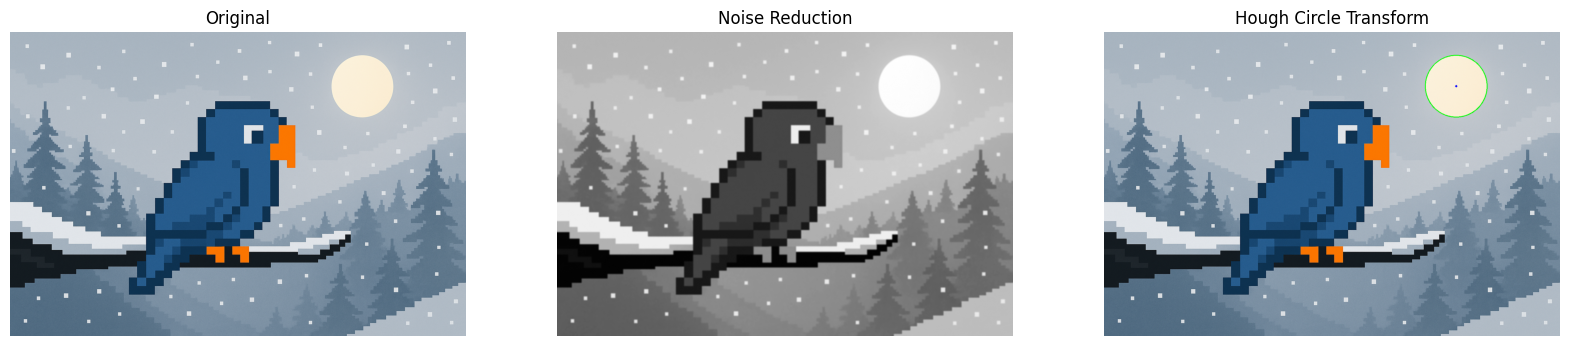

In [9]:
# Reading the sample image
bgr_img = cv2.imdecode(image_bytes_3, cv2.IMREAD_COLOR)
img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
img_edited = img.copy()
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Image pre-processing
blur = cv2.GaussianBlur(img_gray, (9, 9), 2)

# Hough Circle Transform
circles = cv2.HoughCircles(blur, method=cv2.HOUGH_GRADIENT, dp=1, minDist=300, param1=100, param2=40, minRadius=60, maxRadius=120)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        cv2.circle(img_edited, (x, y), r, (0, 255, 0), 2)
        cv2.circle(img_edited, (x, y), 2, (0, 0, 255), 3)

# Creation of an MPL figure for displaying images
create_mpl_figure(20, 10, [img, blur, img_edited], ["Original", "Noise Reduction", "Hough Circle Transform"], color_maps=["gray"])

### Histogram Equalization

**What it does:** Histogram equalization is a technique that improves the contrast of a given image by evaluating the image's histogram (distribution of pixel intensities), and redistributing these pixel intensities to improve contrast across the whole image.

**Why it matters:** Histogram Equalization is used often in medical imaging scenarios, especially in the cases of X-Rays, MRIs and CT scans to improve the clarity of bones, tissues, and other types of objects, be they tumors or otherwise to aid in accurate and clear diagnosis. Additionally, it is often used in surveillance systems, especially in low light applications to create clearer pictures.

**The Code & Output**

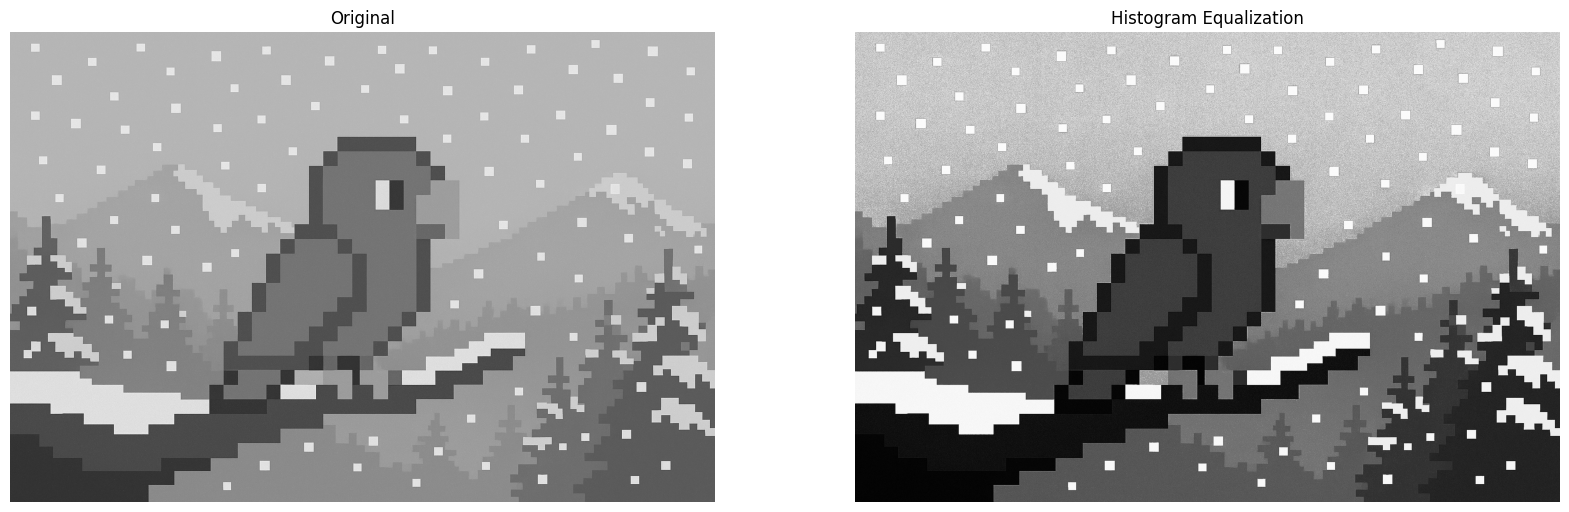

In [10]:
# Reading the sample image
bgr_img = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

# Histogram Equalization
hist_eq = cv2.equalizeHist(img_gray)

# Creation of an MPL figure for displaying images
create_mpl_figure(20, 10, [img_gray, hist_eq], ["Original", "Histogram Equalization"], color_maps=["gray"])

## Conclusion

With this blog, the OpenCV blog series has come to a close. I hope that through the reading of this blog, not only has your understanding of OpenCV increased, but that with this new knowledge has come some ideas for different applications of the various techniques we covered.

If the blog series was helpful to you, please share with others who might be interested in OpenCV and the huge variety of different things that can be achieved with it!

In [11]:
# @title Contact Software Sushi
load_html_from_github('https://raw.githubusercontent.com/SoftwareSushi/marketing-resources/refs/heads/main/html/cta-banner.html')